# Comparaison des modèles (Addiction Population Data)

**Dataset :** Addiction Population Data  
**Variable cible :** `smokes_per_day` nombre de cigarettes consommés par jours 

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

## 1 - Importation des bibliothèques

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)

from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree

import sys
sys.path.append('..')

from sklearn.model_selection import train_test_split
from models.encoder import labelEncoder, oneHotEncoder
from models.ACP import ACP

## 2 - Chargement et preprocessing

On charge le dataset, on convertit les variables textuelles en nombres avec `LabelEncoder` et on traite les donner avec `oneHotEncoder` et `ACP`.
Ensuite on sépare les données en 80% entraînement / 20% test.

In [2]:
df = pd.read_csv('BDD_initial/addiction_population_data.csv')

X_raw = df.drop(columns=['smokes_per_day'])
y     = df['smokes_per_day']

# LabelEncoder
X_le  = labelEncoder(X_raw.copy())

# OneHotEncoder
X_ohe = oneHotEncoder(X_raw.copy())

# ACP
x_acp = ACP(X_ohe, n_components=50)

# Split — même random_state pour comparer sur les mêmes données
X_train_le,  X_test_le,  y_train_le, y_test_le = train_test_split(X_le,  y, test_size=0.2, random_state=42)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe= train_test_split(X_ohe, y, test_size=0.2, random_state=42)

#Split - ACP
X_train_acp, X_test_acp, y_train_acp, y_test_acp = train_test_split(x_acp, y, test_size=0.2, random_state=42)

# label_encoders conservé pour l'exemple étudiant (cell 16)
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    label_encoders[col] = le

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('X_acp shape:', x_acp.shape)
print('Train / Test:', X_train_le.shape[0], '/', X_test_le.shape[0])

X_le  shape: (3000, 26)
X_ohe shape: (3000, 5913)
X_acp shape: (3000, 50)
Train / Test: 2400 / 600


C:\Users\sidsm\AppData\Local\Temp\ipykernel_11856\190953915.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 3. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

Tous les modèles sont présents en 2 versions : 
la version initial avec GridSearchCV est la meilleur mais peut prendre plusieurs minutes, la version 2 avec RandomizedSearchCV est plus courte mais moins précise. 


> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [3]:

from models.random_forest_rgs_v2 import run as run_rf
from models.xgboost import run as run_xgb
from models.knn_rgs_v2 import run as run_knn
from models.naive_bayes_rgs_v2 import run as run_nb_rgs

modeles = {
    'KNN'          : run_knn,
    'Naive Bayes rgs'  : run_nb_rgs,
    'XGBoost'      : run_xgb,
    'Random Forest': run_rf,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')
    resultats[f'{nom} (LE)']  = run_fn(X_train_le,  X_test_le,  y_train_le, y_test_le)
    resultats[f'{nom} (OHE)'] = run_fn(X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe)
    resultats[f'{nom} (ACP)'] = run_fn(X_train_acp, X_test_acp, y_train_acp, y_test_acp)

    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  OHE  R²: {resultats[f'{nom} (OHE)']['optimized']['r2']:.4f}")
    print(f"  ACP R²: {resultats[f'{nom} (ACP)']['optimized']['r2']:.4f}")

print('\nTerminé.')


Entraînement : KNN...
  LE  R²: 0.4989
  OHE  R²: 0.0618
  ACP R²: -0.0200
Entraînement : Naive Bayes rgs...


c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


  LE  R²: 0.6041
  OHE  R²: 0.3422
  ACP R²: 0.1157
Entraînement : XGBoost...
  LE  R²: 0.6222
  OHE  R²: 0.6248
  ACP R²: 0.1359
Entraînement : Random Forest...
  LE  R²: 0.6283
  OHE  R²: 0.6301
  ACP R²: 0.1157

Terminé.


In [ ]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression

# 1. Extraction des vrais modèles (estimateurs Scikit-Learn) 
estimators_acp = [
    ('KNN', resultats['KNN (ACP)']['model']),
    ('xgb', resultats['XGBoost (ACP)']['model']),
    ('rf', resultats['Random Forest (ACP)']['model'])
]

print('\nEntraînement des modèles d\'Ensemble...')

# 2. Voting Regressor (Fait la moyenne des prédictions)
model_voting = VotingRegressor(estimators=estimators_acp)

model_voting.fit(X_train_acp, y_train_acp) 
score_voting_acp = model_voting.score(X_test_acp, y_test_acp)

model_voting.fit(X_train_ohe, y_train_ohe) 
score_voting_ohe = model_voting.score(X_test_ohe, y_test_ohe)

model_voting.fit(X_train_le, y_train_le) 
score_voting_le = model_voting.score(X_test_le, y_test_le)

print(f"  Voting Regressor (ACP) R²: {score_voting_acp:.4f}")
print(f"  Voting Regressor (OHE) R²: {score_voting_ohe:.4f}")
print(f"  Voting Regressor (LE) R²: {score_voting_le:.4f}")

# 3. Stacking Regressor (Utilise un modèle final pour trancher)
model_stack = StackingRegressor(
    estimators=estimators_acp,
    final_estimator=LinearRegression(),
    cv=3 # Ajout de cv=3 pour accélérer l'entraînement interne
)
model_stack.fit(X_train_acp, y_train_acp)
score_stacking_acp = model_stack.score(X_test_acp, y_test_acp)

model_stack.fit(X_train_ohe, y_train_ohe) 
score_stacking_ohe = model_stack.score(X_test_ohe, y_test_ohe)

model_stack.fit(X_train_le, y_train_le) 
score_stacking_le = model_stack.score(X_test_le, y_test_le)

print(f"  Stacking Regressor (ACP) R²: {score_stacking_acp:.4f}")
print(f"  Stacking Regressor (OHE) R²: {score_stacking_ohe:.4f}")
print(f"  Stacking Regressor (LE) R²: {score_stacking_le:.4f}")


print('\nTerminé.')


Entraînement des modèles d'Ensemble...
  Voting Regressor (ACP) R²: 0.0931
  Voting Regressor (OHE) R²: 0.5717
  Voting Regressor (LE) R²: 0.6130
  Stacking Regressor (ACP) R²: 0.1246
  Stacking Regressor (OHE) R²: 0.6190
  Stacking Regressor (LE) R²: 0.6225

Terminé.


## 4. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [4]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
Random Forest (OHE),0.6301,1.4810,1.9283
Random Forest (LE),0.6283,1.5008,1.9327
XGBoost (OHE),0.6248,1.4890,1.9420
XGBoost (LE),0.6222,1.4875,1.9487
Naive Bayes rgs (LE),0.6041,1.5275,1.9949
KNN (LE),0.4989,1.6481,2.2442
Naive Bayes rgs (OHE),0.3422,1.8718,2.5713
XGBoost (ACP),0.1359,2.2135,2.9469
Naive Bayes rgs (ACP),0.1157,2.2519,2.9811


## 5. Visualisation des métriques

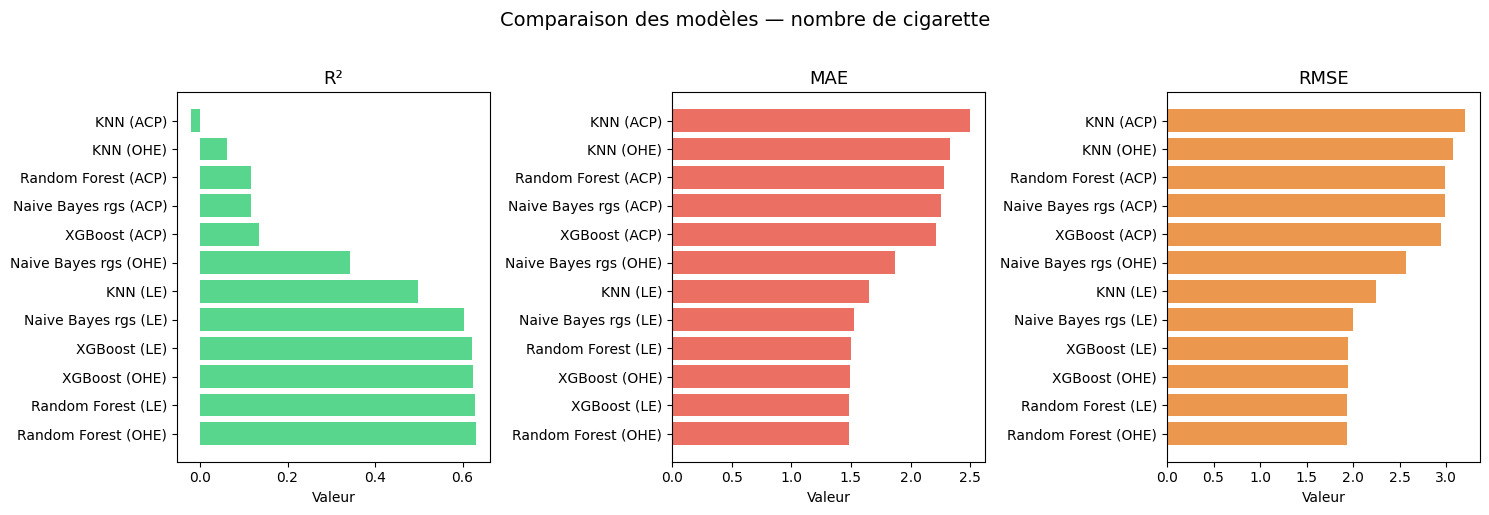

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — nombre de cigarette', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Exemple d'application

On crée un profil de personnes fictive et on demande au modèle de prédire son nombre de cigerette consommée par jour.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [15]:
# exemple d'une personne fictive
personne = {
    'id'                        : 12345,
    'name'                      : 'John Doe',
    'age'                       : 35,
    'gender'                    : 'Male',
    'country'                   : 'USA',
    'city'                      : 'New York',
    'education_level'           : 'University',
    'employment_status'         : 'Self-Employed',
    'annual_income_usd'         : 100500,
    'marital_status'            : 'Single',
    'children_count'            : 0,
    'drinks_per_week'           : 5,
    'age_started_smoking'       : 18,
    'age_started_drinking'      : 20,
    'attempts_to_quit_smoking'  : 1,
    'attempts_to_quit_drinking' : 0,
    'has_health_issues'         : False,
    'mental_health_status'      : 'Moderate',
    'exercise_frequency'        : 'Rarely',
    'diet_quality'              : 'Poor',
    'sleep_hours'               : 7.0,
    'bmi'                       : 25.5,
    'social_support'            : 'Low',
    'therapy_history'           : 'None',
    'addict_smoke'              : 1,
    'addict_drink'              : 0,
}

# Trouve le meilleur modèle selon R²
meilleur_cle = max(resultats, key=lambda k: resultats[k]['optimized']['r2'])
meilleur_r2  = resultats[meilleur_cle]['optimized']['r2']

personne_df = pd.DataFrame([personne])

# Encodage
personne_enc = {}
for col, val in personne.items():
    if col in label_encoders:
        if val in label_encoders[col].classes_:
            personne_enc[col] = label_encoders[col].transform([val])[0]
        else:
            # Handle unseen label by assigning a default value (e.g., 0)
            personne_enc[col] = 0
    else:
        personne_enc[col] = val

if '(LE)' in meilleur_cle:
    X_personne = pd.DataFrame([personne_enc])[X_le.columns]
else:
    personne_ohe_raw = oneHotEncoder(personne_df.copy())
    X_personne       = personne_ohe_raw.reindex(columns=X_ohe.columns, fill_value=0)

score_predit = resultats[meilleur_cle]['model'].predict(X_personne)[0]

print("=== Profil de la personne ===")
for k, v in personne.items():
    print(f"  {k:<35} : {v}")

print(f"\n Modèle utilisé : {meilleur_cle}  (R² = {meilleur_r2:.4f})")
print(f" Cigarettes prédites par jour : {score_predit:.1f}")

if score_predit >= 15:
    print("    → Fumeur intensif")
elif score_predit >= 5:
    print("    → Fumeur modéré")
else:
    print("    → Non-fumeur ou très occasionnel")

=== Profil de la personne ===
  id                                  : 12345
  name                                : John Doe
  age                                 : 35
  gender                              : Male
  country                             : USA
  city                                : New York
  education_level                     : University
  employment_status                   : Self-Employed
  annual_income_usd                   : 100500
  marital_status                      : Single
  children_count                      : 0
  drinks_per_week                     : 5
  age_started_smoking                 : 18
  age_started_drinking                : 20
  attempts_to_quit_smoking            : 1
  attempts_to_quit_drinking           : 0
  has_health_issues                   : False
  mental_health_status                : Moderate
  exercise_frequency                  : Rarely
  diet_quality                        : Poor
  sleep_hours                         : 7.0
  bmi     

## 7. Conclusion

Ce notebook compare les modèles de régression entraînés sur le dataset `Addiction Population Data`.  
Le meilleur modèle est sélectionné selon le R² le plus élevé et le MAE/RMSE les plus faibles. Au vu des résultats observés dans les parties 4 et 5, le Random Forest s'impose comme le modèle le plus performant pour prédire le nombre de cigarettes consommées par jour, avec un R² de 0.6301 et les valeurs de MAE et RMSE les plus faibles parmi les modèles testés.

**Pour intégrer un nouveau modèle :**
1. Créer `models/nom_du_modele.py` avec une fonction `run(X_train, X_test, y_train, y_test) -> dict`
2. La fonction doit retourner au minimum : `{'optimized': {'r2', 'mae', 'rmse'}, 'model': estimateur}`
3. Décommenter la ligne d'import correspondante dans la cellule 4